In [168]:
from datetime import datetime
from pathlib import Path
import glob
import os

import geopandas as gpd
from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

from thomas2024.calibration import assemble_thresholds, lookup_pop_at_risk


display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))
pd.set_option('display.max_rows', 50)

In [2]:
storm_set_params = {
    "STORM_constant": ("STORM", 2000, None, None),
    "STORM_CNRM-CM6-1-HR": ("STORM", 2050, "RCP8.5", "CNRM"),
    "STORM_CMCC-CM2-VHR4": ("STORM", 2050, "RCP8.5", "CMCC"),
    "STORM_EC-Earth3P-HR": ("STORM", 2050, "RCP8.5", "EC-Earth"),
    "STORM_HadGEM3-GC31-HM": ("STORM", 2050, "RCP8.5", "HadGEM3"),

    "IRIS_PRESENT": ("IRIS", 2000, None, None),
    "IRIS_SSP5-2050": ("IRIS", 2050, "SSP5-8.5", None),

    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2010": ("CHAZ", 2010, None, "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2010": ("CHAZ", 2010, None, "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2010": ("CHAZ", 2010, None, "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2010": ("CHAZ", 2010, None, "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2010": ("CHAZ", 2010, None, "MIROC6"),
    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "MIROC6"),

    "emanuel_ssp-585_gcm-cesm2_epoch-2005": ("Emanuel", 2005, None, "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2005": ("Emanuel", 2005, None, "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2005": ("Emanuel", 2005, None, "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2005": ("Emanuel", 2005, None, "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2005": ("Emanuel", 2005, None, "UKMO6"),
    "emanuel_ssp-585_gcm-cesm2_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "UKMO6"),
}

group_colours = {
    "IRIS": "lightgreen",
    "STORM": "plum",
    "CHAZ": "pink",
    "MIT": "lightblue",
}

sample_countries = (
    "NIC",
    "GTM",
    "USA",
    "DOM",
    "CUB",
    "MEX",
    "LKA",
    "MDG",
    "MOZ",
    "MMR",
    "BGD",
    "IND",
    "TWN",
    "KOR",
    "VNM",
    "PHL",
    "JPN",
    "CHN",
)

In [153]:
# Input data paths
country_thresholds_path = Path("data/20260907_country_thresholds.csv")
income_thresholds_path = Path("data/20260907_income_thresholds.csv")
wb_income_path = Path("data/OGHIST_2026_07_15.xlsx")
results_dir = Path("/data/tc-grid/open-gira/results")

# Output paths
plot_dir = Path("../plots")

thresholds_by_country = assemble_thresholds(wb_income_path, income_thresholds_path, country_thresholds_path)

metrics = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/metrics.pq"))))])
metrics = metrics.dropna(how="all")
metrics["gamma_index"] = metrics["gamma_index"].astype(float)
metrics = metrics.rename(columns={c: f"net_{c}" for c in metrics.columns})

nodes = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/nodes.geoparquet"))))])
node_pop = nodes.loc[:, ["iso_a3", "population"]].dropna().groupby("iso_a3").sum().rename(columns={"population": "total_pop"})

risk = []
for atmosphere, (model, epoch, scenario, gcm) in storm_set_params.items():
    df = pd.read_parquet(results_dir / f"power/by_storm_set/{atmosphere}/disruption/drivers.pq")
    df["model"] = model
    df["epoch"] = epoch
    df["scenario"] = scenario
    df["gcm"] = gcm
    risk.append(lookup_pop_at_risk(df, thresholds_by_country))

df = pd.concat(risk)
df = df.merge(metrics.reset_index(), on="iso_a3")
df = df.merge(node_pop.reset_index(), on="iso_a3")
df["wind_exceedance_ms-1"] = df["max_wind_speed_ms"] - df["threshold_ms-1"]
df["pop_at_risk_ratio"] = df["pop_at_risk"] / df["total_pop"]
df = df[df["pop_at_risk_ratio"] > 0]


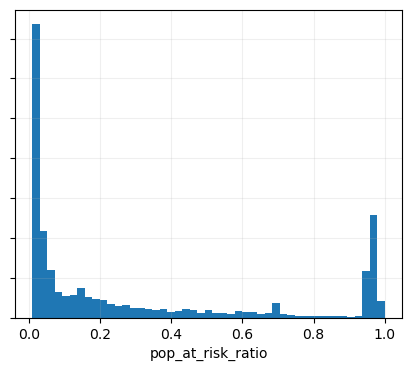

In [132]:
f, ax = plt.subplots(figsize=(5, 4))
freq, edges, patches = ax.hist(df.pop_at_risk_ratio, bins=np.linspace(0.01, 1, 48), density=True)
ax.set_xlabel("pop_at_risk_ratio")
ax.grid(which="both", alpha=0.2)
labels = ax.set_yticklabels([])

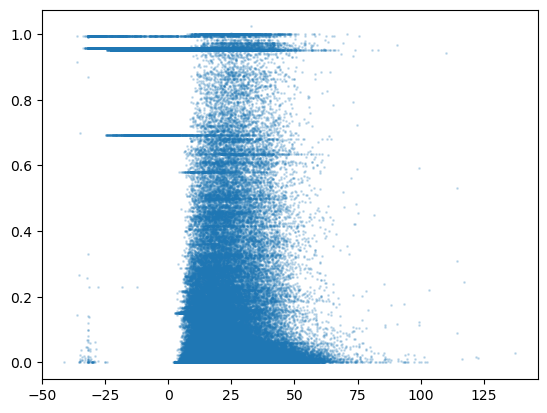

In [131]:
f, ax = plt.subplots()
ax.scatter(df["wind_exceedance_ms-1"], df["pop_at_risk_ratio"], alpha=0.2, s=1)

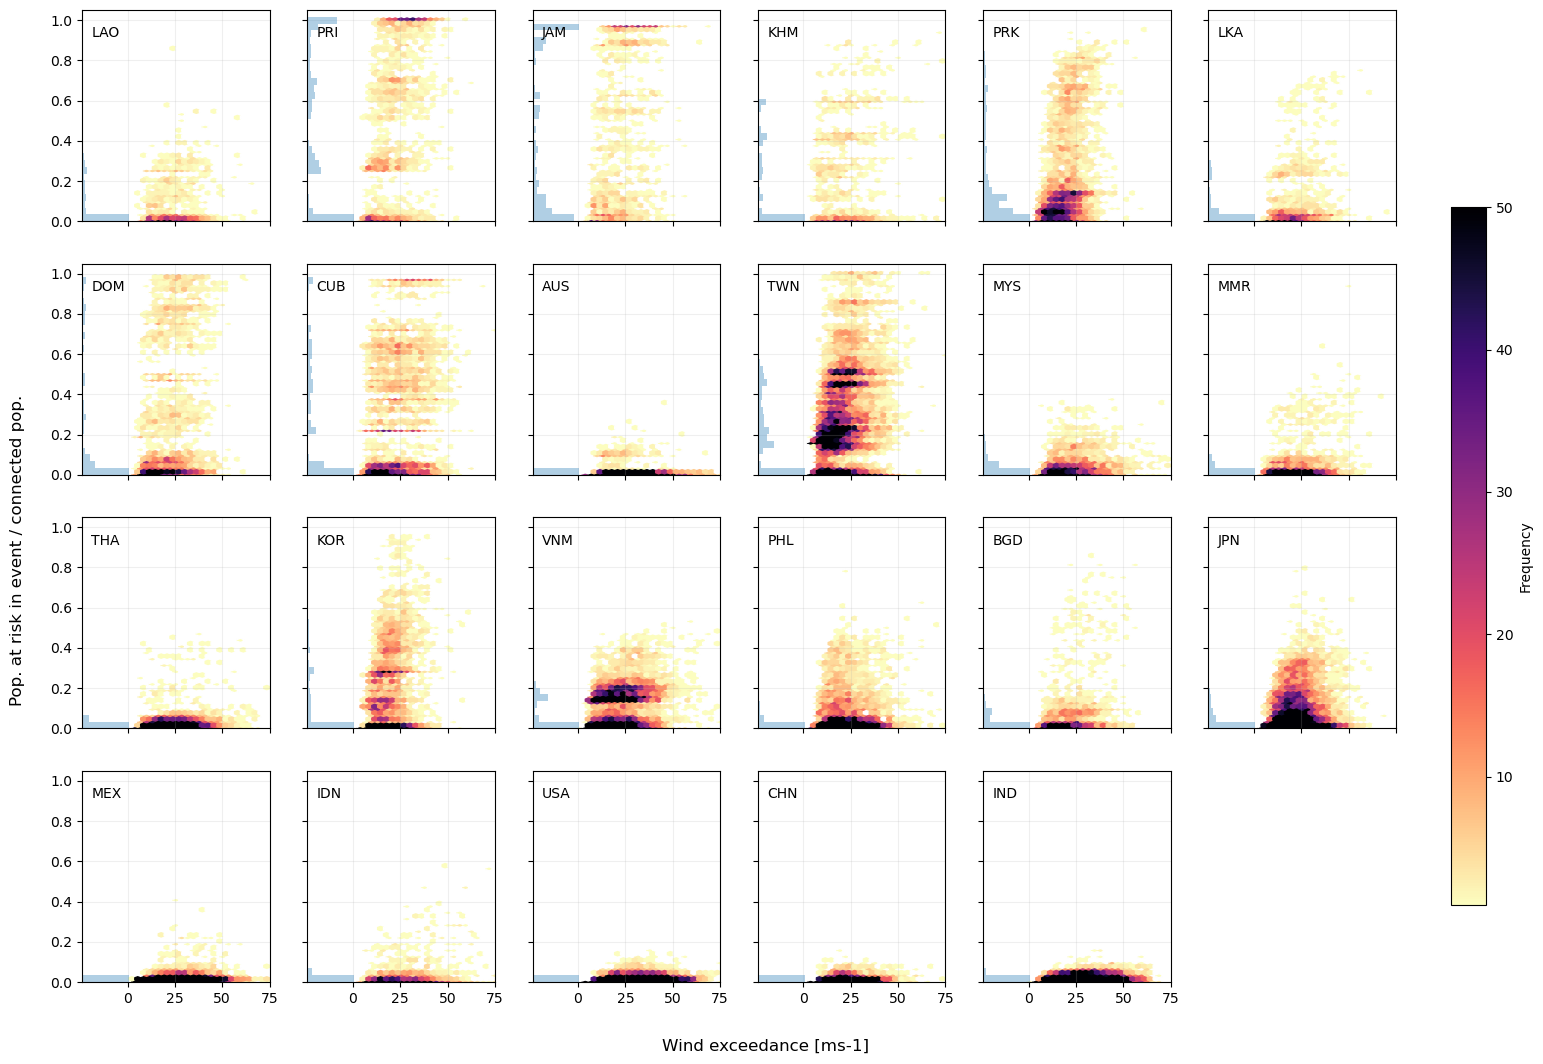

In [ ]:
MIN_POP = 1E6
MIN_OBS = 1E3
DROP_COUNTRIES = ["NIC", "GTM", "MOZ", "MDG"]
MIN_EXCEEDANCE = -24
MAX_EXCEEDANCE = 75
N_BINS = 32
QUANTILES = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]

obs_per_iso_a3 = df.loc[:, ["iso_a3", "pop_at_risk"]].groupby("iso_a3").count().rename(columns={"pop_at_risk": "count"})
valid_iso_a3 = pd.Series(
    list(
        set(obs_per_iso_a3[obs_per_iso_a3["count"] > MIN_OBS].index)
        & set(df[df.total_pop > MIN_POP].iso_a3.unique())
        - set(DROP_COUNTRIES)
    )
)
iso_a3_by_pop = df.loc[:, ["iso_a3", "total_pop"]].groupby("iso_a3").first()
iso_a3_by_pop = iso_a3_by_pop.loc[valid_iso_a3].sort_values("total_pop")

n_cols = 6
n_rows = len(iso_a3_by_pop) // n_cols + 1
vmin = 1
vmax = 50
f, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
cmap = plt.get_cmap("magma_r")
cmap.set_under("white")

for i, (iso_a3, ax) in enumerate(zip(iso_a3_by_pop.index, axes.ravel())):
    data = df[(df.iso_a3 == iso_a3) & (df["wind_exceedance_ms-1"] < MAX_EXCEEDANCE)]
    hb = ax.hexbin(
        data["wind_exceedance_ms-1"],
        data["pop_at_risk_ratio"],
        gridsize=(N_BINS, N_BINS),
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        extent=(MIN_EXCEEDANCE, MAX_EXCEEDANCE, 0, 1),
    )
    ax.set_xlim(MIN_EXCEEDANCE, MAX_EXCEEDANCE)
    ax.set_ylim(0, 1.05)

    ratio = data["pop_at_risk_ratio"].dropna()
    hist_counts, hist_edges = np.histogram(
        ratio,
        bins=np.linspace(0, 1.05, 32),
    )

    x0, x1 = ax.get_xlim()
    hist_width = 0.25 * (x1 - x0)
    max_count = hist_counts.max()
    widths = hist_counts / max_count * hist_width
    ax.barh(
        (hist_edges[:-1] + hist_edges[1:]) / 2,
        widths,
        height=np.diff(hist_edges),
        left=x0,
        align="center",
        alpha=0.35,
        edgecolor="none",
        zorder=2,
    )

    if i // n_cols != n_rows - 1:
        ax.set_xticklabels([])
    if i % n_cols != 0:
        ax.set_yticklabels([])
    ax.grid(which="both", alpha=0.2)
    ax.text(0.05, 0.87, iso_a3, transform=ax.transAxes)

for ax in axes.ravel()[len(iso_a3_by_pop):]:
    ax.axis("off")

f.supxlabel("Wind exceedance [ms-1]", y=0.08)
f.supylabel("Pop. at risk in event / connected pop.", x=0.08)
f.colorbar(
    hb,
    ax=axes.ravel().tolist(),
    location="right",
    pad=0.02,
    fraction=0.025,
    label="Frequency"
)
plt.subplots_adjust(bottom=0.14, left=0.12, top=0.95, right=0.85)
f.savefig("pop_at_risk_ratio_vs_exceedance_by_country.png", bbox_inches="tight", pad_inches=0.4)